# 507: Mean-Based Waterfall Contribution Plots, Stratified by Net-Zero-CO2 Timing

`506_waterfall_mean_based.ipynb` pools every scenario within a `scenario_group` together
when computing the mean-of-means waterfall, regardless of when each scenario reaches
net-zero CO2. Since the delta components are extracted over the window from
`year_netzero_co2` to 2100, and `year_netzero_co2` ranges from 2034 to 2090 across the
784-scenario universe, that window's length varies by more than 3x between scenarios
(as little as ~10 years, as much as ~66 years) - pooling them together conflates
genuine methodological effects with this duration heterogeneity.

A straightforward per-year rescaling (dividing each delta by its window length) is not
used here, because it would misrepresent the physics: the `NonCO2_GHG` component is
dominated by CH4 forcing decay, which is close to exponential with an ~12-year
atmospheric lifetime - most of that decline happens in the first 20-30 years after
net-zero regardless of *when* net-zero occurs, so a linear per-year rate would
understate the decline for short-window (late-achieving) scenarios and overstate it for
long-window (early-achieving) scenarios.

Instead, this notebook **stratifies**: scenarios are bucketed by `year_netzero_co2`,
and 506's exact mean-of-means waterfall design (same components, same colors, same
additive-by-construction mean-based aggregation) is reproduced separately for each
bucket. This keeps the full sample (no scenarios dropped) and makes any
duration-driven pattern visible rather than averaging it away.

**Buckets** (decade-aligned, with the sparse tails merged into their nearest full
decade - the 784-scenario universe has only 5 scenarios in the 2030s and spans just
2090 as a single year beyond the 2080s):

| Bucket | Years | Scenarios (NZCO2)/(NZCO2-hold) count |
|---|---|---|
| ≤2049 | 2030-2049 | ~50 |
| 2050s | 2050-2059 | ~144 |
| 2060s | 2060-2069 | ~202 |
| 2070s | 2070-2079 | ~176 |
| ≥2080 | 2080-2090 | ~212 |

(NZGHG-based groups have fewer scenarios per bucket, since that's a subset that also
achieves net-zero Kyoto GHG.)

In [1]:
import os
from pathlib import Path

import dotenv
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

dotenv.load_dotenv()

OUTPUT_FOLDER = Path(os.environ["OUTPUT_FOLDER"])
PLOT_FOLDER = OUTPUT_FOLDER / "plots"
PLOT_FOLDER.mkdir(parents=True, exist_ok=True)

MANIFEST_ID = "regenerated"
METRICS_FILE = OUTPUT_FOLDER / f"500b_component_metrics_extended_{MANIFEST_ID}.csv"

GROUPS = [
    "Scenarios (NZCO2)",
    "Scenarios (NZGHG)",
    "Stylised Variants (NZCO2-hold)",
    "Stylised Variants (NZGHG-hold)",
]

COMPONENTS = ["ANTHROPOGENIC", "CO2_NZCO2", "CO2_Negative", "NonCO2_GHG", "Residual"]
DELTA_COMPONENTS = ["CO2_NZCO2", "CO2_Negative", "NonCO2_GHG", "Residual"]

In [2]:
metrics_df = pd.read_csv(METRICS_FILE, index_col=0)
print(f"Total rows: {len(metrics_df)}")
metrics_df["scenario_group"].value_counts()

Total rows: 1405200


scenario_group
Scenarios (NZCO2)                 470400
Stylised Variants (NZCO2-hold)    470400
Stylised Variants (NZGHG-hold)    232200
Scenarios (NZGHG)                 232200
Name: count, dtype: int64

## Bucket Scenarios by Net-Zero-CO2 Timing

In [3]:
# Decade-aligned buckets, with the sparse 2030s folded into the 2040s and the single
# year 2090 folded into the 2080s (see markdown intro for scenario counts).
BUCKET_ORDER = ["\u22642049", "2050s", "2060s", "2070s", "\u22652080"]
BUCKET_BIN_EDGES = [2029, 2049, 2059, 2069, 2079, 2090]

metrics_df["netzero_bucket"] = pd.cut(
    metrics_df["year_netzero_co2"],
    bins=BUCKET_BIN_EDGES,
    labels=BUCKET_ORDER,
    include_lowest=True,
)

# Scenario-level (not per-run_id) counts per (scenario_group, bucket)
scenario_counts = (
    metrics_df
    .drop_duplicates(subset=["model", "scenario", "scenario_group"])
    .groupby(["scenario_group", "netzero_bucket"], observed=True)
    .size()
    .unstack("netzero_bucket")
    .reindex(columns=BUCKET_ORDER)
)
scenario_counts

netzero_bucket,≤2049,2050s,2060s,2070s,≥2080
scenario_group,,,,,
Scenarios (NZCO2),50,144,202,176,212
Scenarios (NZGHG),28,93,138,97,31
Stylised Variants (NZCO2-hold),50,144,202,176,212
Stylised Variants (NZGHG-hold),28,93,138,97,31


## Per-Scenario Means and Mean-of-Means Group Statistics

Identical to 506's `calc_mean_of_mean_by_group` / per-scenario-mean logic - reused
unchanged, just called once per `netzero_bucket` on a pre-filtered subset of
`metrics_df`, rather than once on the full pooled dataset.

In [4]:
def calc_scenario_means(df, groups):
    """Per-scenario MEAN (across ensemble members) of the endpoint GSAT levels - used
    for the start (NZCO2) and end (2100) bars. Identical to 506's cell 4, factored out
    so it can be called per-bucket."""
    value_cols = [c for c in df.columns if c.startswith("GSAT|")]
    scenario_means = df.groupby(["model", "scenario", "scenario_group"])[value_cols].mean()
    return {
        group: scenario_means[scenario_means.index.get_level_values("scenario_group") == group]
        for group in groups
    }


def calc_mean_of_mean_by_group(metrics_df, components, groups, extraction_mode="netzero_co2"):
    """For each delta component, compute per-scenario mean (across members), then the
    mean-of-means across scenarios (the additive bar-height statistic), alongside
    percentile-of-percentile error bars (p05/p17/p83/p95), per scenario_group.

    Unchanged from 506 - mirrors 503's calc_percentile_of_percentile/calc_pop_by_group,
    with "median" replaced by "mean" for the central bar-height statistic only.
    """
    delta_cols = [f"GSAT|{c}|delta_{extraction_mode}" for c in components if f"GSAT|{c}|delta_{extraction_mode}" in metrics_df.columns]
    quantiles = {"p05": 0.05, "p17": 0.17, "p83": 0.83, "p95": 0.95}

    scenario_stats = metrics_df.groupby(["model", "scenario", "scenario_group"])[delta_cols].agg(
        ["mean"] + [lambda x, q=q: x.quantile(q) for q in quantiles.values()]
    )
    stat_names = ["mean"] + list(quantiles.keys())
    scenario_stats.columns = [f"{col}|{name}" for col in delta_cols for name in stat_names]

    results = {}
    for group in groups:
        gdf = scenario_stats[scenario_stats.index.get_level_values("scenario_group") == group]
        rows = {}
        for comp in components:
            col_base = f"GSAT|{comp}|delta_{extraction_mode}"
            if f"{col_base}|mean" not in gdf.columns:
                continue
            rows[comp] = {
                "mean_of_mean": gdf[f"{col_base}|mean"].mean(),
                "p05_of_p05": gdf[f"{col_base}|p05"].quantile(0.05),
                "p17_of_p17": gdf[f"{col_base}|p17"].quantile(0.17),
                "p83_of_p83": gdf[f"{col_base}|p83"].quantile(0.83),
                "p95_of_p95": gdf[f"{col_base}|p95"].quantile(0.95),
            }
        if rows:
            df = pd.DataFrame(rows).T
            df.index.name = "Component"
            results[group] = df
    return results

## Mean-Based Waterfall Plot (unchanged from 506)

In [5]:
def create_waterfall_plot_mean(pop_stats, scenario_means_subset, title, ax):
    color_start = '#0F0FFF'
    color_delta = {
        'CO2_NZCO2': '#FF0B00',
        'CO2_Negative': '#00E3DB',
        'NonCO2_GHG': '#4CA2FF',
        'Residual': '#C92EB9'
    }
    color_end = '#0F0FFF'

    error_kw = {'ecolor': 'black', 'alpha': 0.5, 'capsize': 4, 'capthick': 1.2}
    bar_kw = {'width': 0.6, 'edgecolor': 'black', 'linewidth': 0.8}

    # Start (NZCO2) and end (2100) bars: mean of per-scenario means, with p17/p83
    # error bars from the per-scenario-mean distribution across scenarios
    nzco2_mean = scenario_means_subset["GSAT|ANTHROPOGENIC|netzero_co2"].mean()
    nzco2_p17 = scenario_means_subset["GSAT|ANTHROPOGENIC|netzero_co2"].quantile(0.17)
    nzco2_p83 = scenario_means_subset["GSAT|ANTHROPOGENIC|netzero_co2"].quantile(0.83)

    y2100_mean = scenario_means_subset["GSAT|ANTHROPOGENIC|2100"].mean()
    y2100_p17 = scenario_means_subset["GSAT|ANTHROPOGENIC|2100"].quantile(0.17)
    y2100_p83 = scenario_means_subset["GSAT|ANTHROPOGENIC|2100"].quantile(0.83)

    x_positions = [0, 1, 2, 3, 4, 5]
    labels = ["NZCO2\n[ANTHRO]", "ZEC*", "CO$_2$\nNeg", "Non-CO$_2$\nGHG", "Resid.", "2100\n[ANTHRO]"]

    ax.bar(0, nzco2_mean, color=color_start,
           yerr=[[nzco2_mean - nzco2_p17], [nzco2_p83 - nzco2_mean]],
           error_kw=error_kw, **bar_kw)

    # Boundary levels for the connector lines: where each bar ends and the next starts
    half_width = bar_kw["width"] / 2
    connector_kw = {"linestyle": ":", "color": "gray", "linewidth": 1, "zorder": 1}
    boundaries = [nzco2_mean]

    bottom = nzco2_mean
    for i, comp in enumerate(DELTA_COMPONENTS):
        if comp in pop_stats.index:
            delta_mean = pop_stats.loc[comp, "mean_of_mean"]
            delta_p17 = pop_stats.loc[comp, "p17_of_p17"]
            delta_p83 = pop_stats.loc[comp, "p83_of_p83"]

            ax.bar(i + 1, delta_mean, bottom=bottom, color=color_delta[comp],
                   yerr=[[delta_mean - delta_p17], [delta_p83 - delta_mean]],
                   error_kw=error_kw, **bar_kw)
            bottom += delta_mean
            boundaries.append(bottom)

    ax.bar(5, y2100_mean, color=color_end,
           yerr=[[y2100_mean - y2100_p17], [y2100_p83 - y2100_mean]],
           error_kw=error_kw, **bar_kw)

    # Dotted connector lines between each bar's ending level and the next bar's start
    for i, boundary in enumerate(boundaries):
        ax.plot([i + half_width, i + 1 - half_width], [boundary, boundary], **connector_kw)

    ax.set_xticks(x_positions)
    ax.set_xticklabels(labels, fontsize=12)
    ax.set_ylabel("GSAT (\u00b0C)", fontsize=13)
    ax.set_title(title, fontsize=14)
    ax.tick_params(axis='y', labelsize=11)
    ax.grid(alpha=0.3, axis='y')
    ax.axhline(y=0, color='gray', linestyle='-', linewidth=0.5)

    return ax, bottom, y2100_mean

## One Waterfall Figure per Net-Zero-Timing Bucket

Same 2x2 grid across the four scenario groups as 506, produced once per bucket. Each
figure gets its own y-limits (based on that bucket's own bar range with a fixed
margin), since early- and late-achieving scenarios sit at very different absolute GSAT
levels and a single shared range (like 506's fixed 1.4-2.1°C, tuned for the pooled
data) would not fit every bucket well.

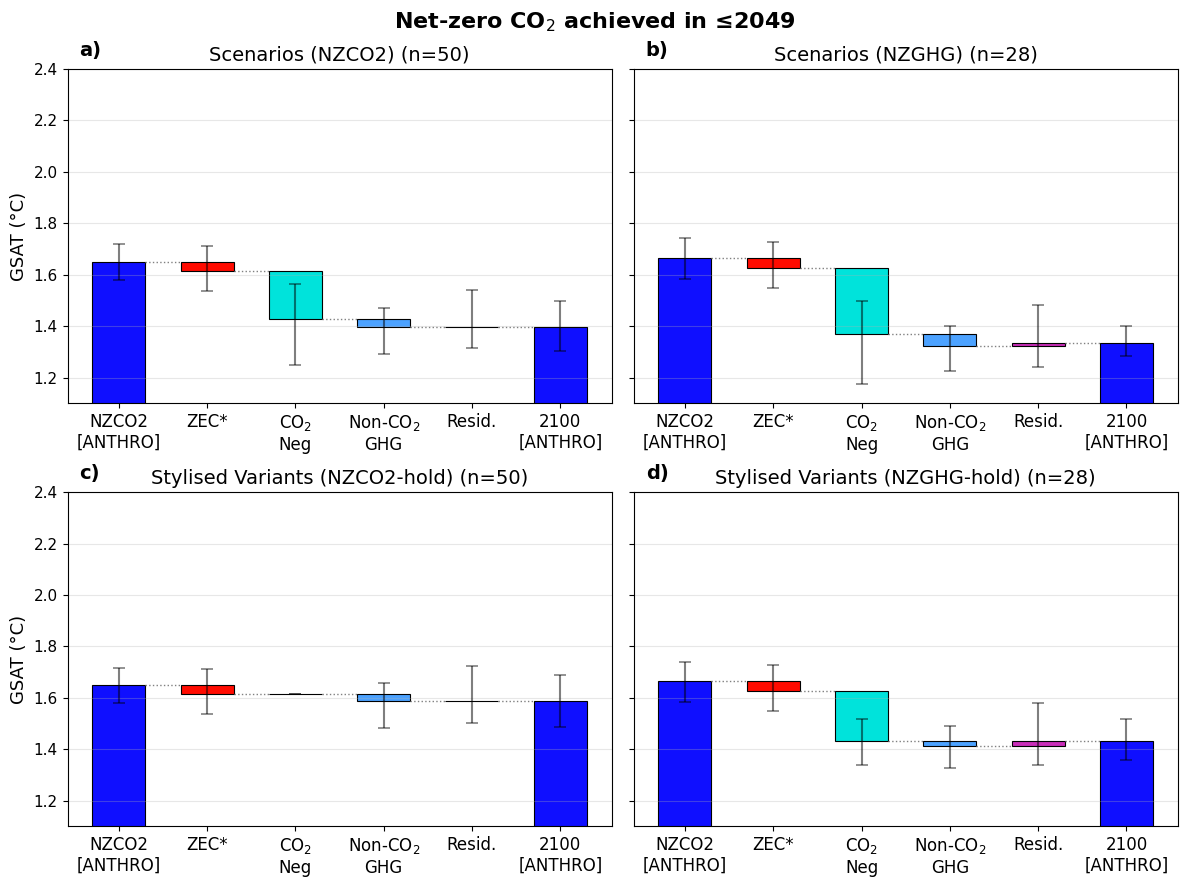

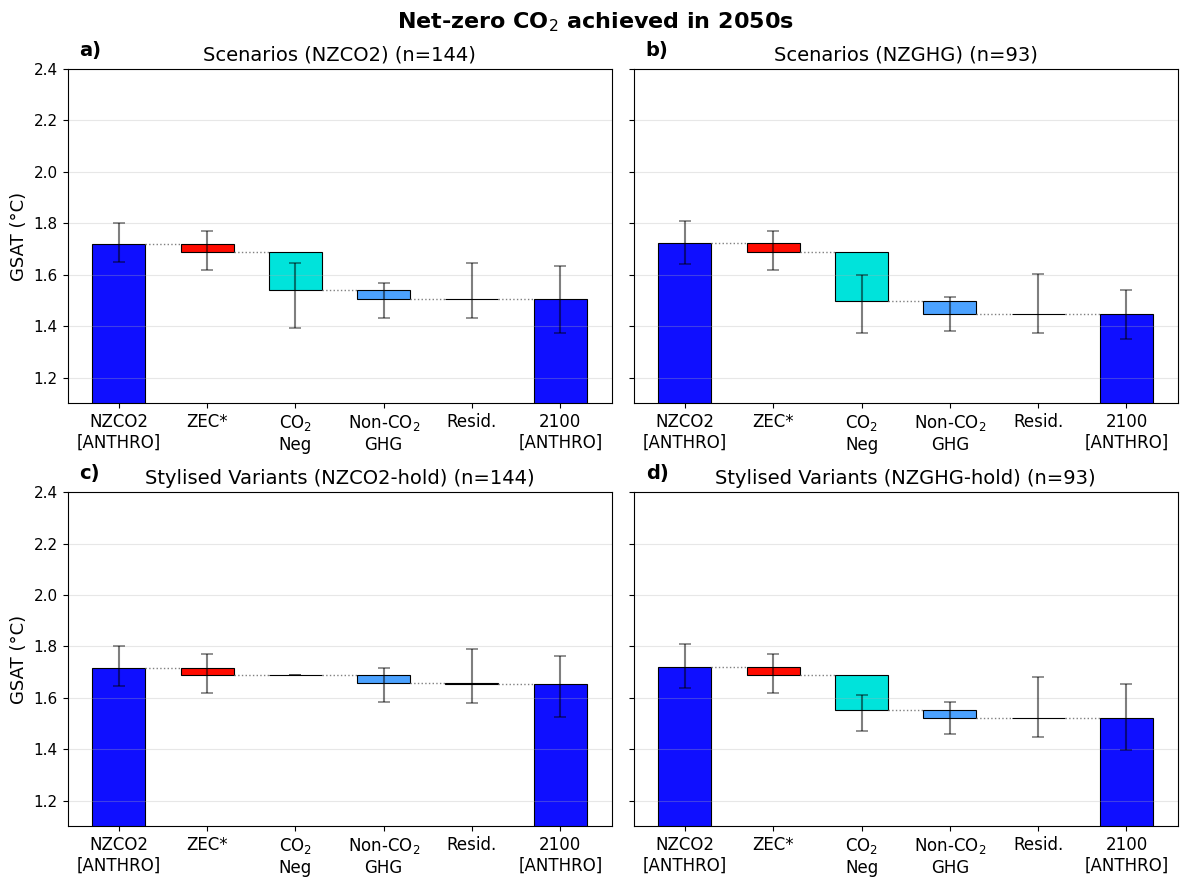

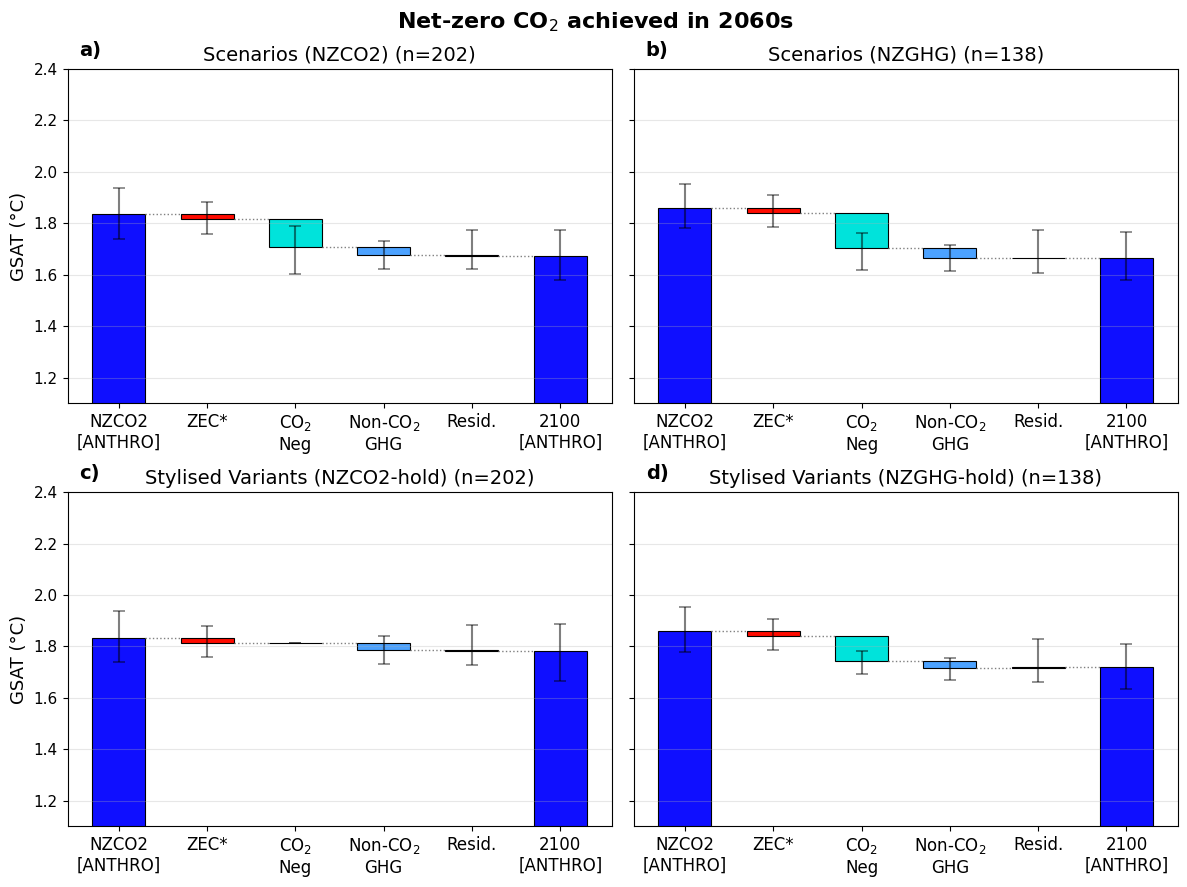

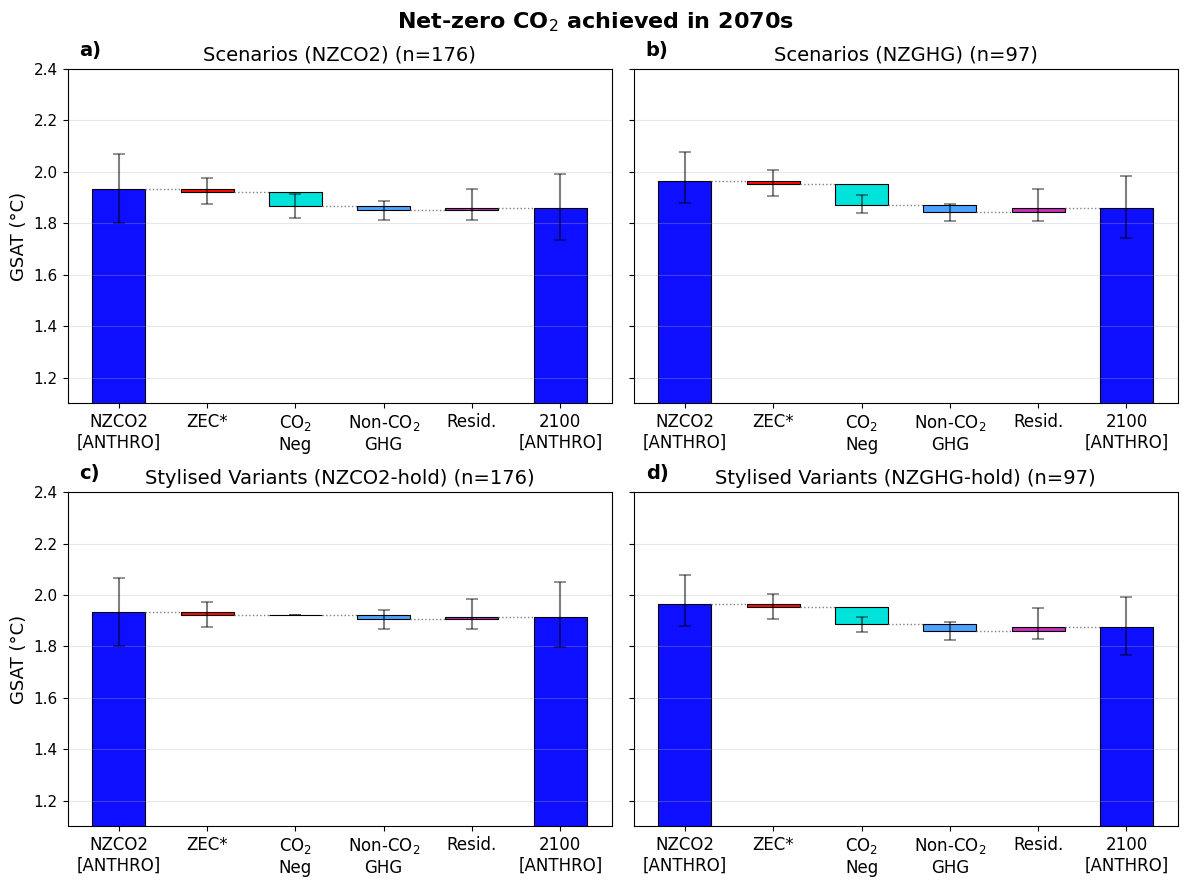

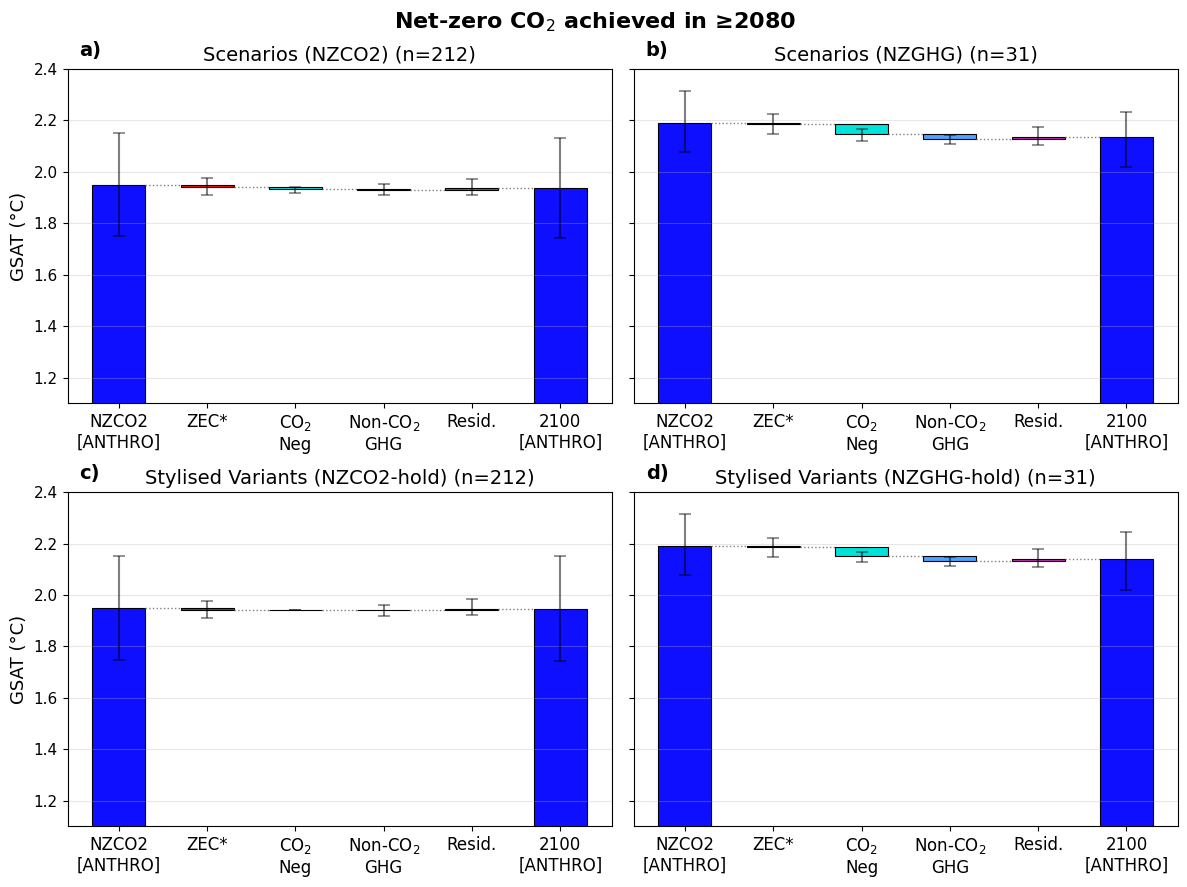

In [6]:
def sanitize_bucket_label(bucket):
    return str(bucket).replace("≤", "le").replace("≥", "ge")


additivity_check = []

for bucket in BUCKET_ORDER:
    bucket_df = metrics_df[metrics_df["netzero_bucket"] == bucket]

    scenario_means_by_group = calc_scenario_means(bucket_df, GROUPS)
    mean_of_mean_by_group = calc_mean_of_mean_by_group(bucket_df, DELTA_COMPONENTS, GROUPS, "netzero_co2")

    present_groups = [g for g in GROUPS if g in mean_of_mean_by_group and len(scenario_means_by_group[g]) > 0]
    if not present_groups:
        print(f"Bucket {bucket}: no scenarios in any group, skipping")
        continue

    fig, axes = plt.subplots(2, 2, figsize=(12, 9), sharey=True)
    axes = axes.flatten()

    for ax, group in zip(axes, GROUPS):
        if group not in present_groups:
            ax.set_title(f"{group} (no scenarios)", fontsize=14)
            ax.axis("off")
            continue

        _, stacked_total, y2100_mean = create_waterfall_plot_mean(
            mean_of_mean_by_group[group],
            scenario_means_by_group[group],
            f"{group} (n={len(scenario_means_by_group[group])})",
            ax,
        )
        additivity_check.append({
            "netzero_bucket": bucket, "scenario_group": group,
            "stacked_total": stacked_total, "y2100_mean": y2100_mean,
            "abs_diff": abs(stacked_total - y2100_mean),
        })

    for ax in axes[1::2]:
        ax.set_ylabel("")

    # Same fixed range as 506, reused here (rather than a per-bucket auto range) so
    # all five figures are directly, visually comparable to each other and to 506.
    for ax in axes:
        ax.set_ylim(1.1, 2.4)

    fig.suptitle(f"Net-zero CO$_2$ achieved in {bucket}", fontsize=16, fontweight="bold")
    plt.tight_layout()

    labels_ab = ["a)", "b)", "c)", "d)"]
    for ax, label in zip(axes, labels_ab):
        x = ax.get_position().x0
        y = ax.get_position().y1
        fig.text(x + 0.01, y + 0.01, label, fontsize=14, fontweight="bold", va="bottom")

    plt.savefig(PLOT_FOLDER / f"507_waterfall_contributions_mean_based_{sanitize_bucket_label(bucket)}.png", dpi=150, bbox_inches="tight")
    plt.show()

## Verify Additivity

Same check as 506, across every (bucket, scenario_group) combination.

In [7]:
additivity_df = pd.DataFrame(additivity_check)
print("Stacked-total vs. 2100-endpoint-bar check (mean-based, should be ~0):")
print(additivity_df.to_string(index=False))
assert additivity_df["abs_diff"].max() < 1e-8, "Waterfall bars do not add up exactly - unexpected"
print("\nPASS: stacked component bars sum to the 2100 endpoint bar exactly, for every (bucket, scenario_group) combination.")

Stacked-total vs. 2100-endpoint-bar check (mean-based, should be ~0):
netzero_bucket                 scenario_group  stacked_total  y2100_mean     abs_diff
         ≤2049              Scenarios (NZCO2)       1.398256    1.398256 4.440892e-16
         ≤2049              Scenarios (NZGHG)       1.335203    1.335203 0.000000e+00
         ≤2049 Stylised Variants (NZCO2-hold)       1.587527    1.587527 2.220446e-16
         ≤2049 Stylised Variants (NZGHG-hold)       1.433431    1.433431 2.220446e-16
         2050s              Scenarios (NZCO2)       1.504350    1.504350 0.000000e+00
         2050s              Scenarios (NZGHG)       1.445984    1.445984 2.220446e-16
         2050s Stylised Variants (NZCO2-hold)       1.652818    1.652818 0.000000e+00
         2050s Stylised Variants (NZGHG-hold)       1.523280    1.523280 2.220446e-16
         2060s              Scenarios (NZCO2)       1.674350    1.674350 2.220446e-16
         2060s              Scenarios (NZGHG)       1.664902    1.6649

## Cross-Decade Comparison

The waterfalls above make each bucket's own internal decomposition easy to read, but
hard to compare *across* buckets at a glance (five separate figures). This summarizes
the same underlying numbers - for `Scenarios (NZCO2)` - in one figure with two panels,
one bar group per bucket:

- **Panel a)**: mean GSAT at the net-zero-CO2 year and at 2100, side by side per bucket
  - the absolute start/end levels.
- **Panel b)**: the four delta components (`ZEC*`, `CO2 Neg`, `Non-CO2 GHG`, `Residual`)
  stacked per bucket - the decomposition of the NZCO2-to-2100 change itself, without
  the absolute GSAT levels panel a) already shows.

No error bars here (stacking obscures per-segment uncertainty ranges) - see the
waterfall figures above for the full percentile-of-percentile ranges per bucket.


In [8]:
comparison_rows = []
for group in GROUPS:
    for bucket in BUCKET_ORDER:
        bucket_df = metrics_df[
            (metrics_df["netzero_bucket"] == bucket)
            & (metrics_df["scenario_group"] == group)
        ]
        if bucket_df.empty:
            continue

        scenario_means = calc_scenario_means(bucket_df, [group])[group]
        pop_stats = calc_mean_of_mean_by_group(bucket_df, DELTA_COMPONENTS, [group], "netzero_co2")[group]

        row = {
            "scenario_group": group,
            "bucket": bucket,
            "n": len(scenario_means),
            "nzco2_mean": scenario_means["GSAT|ANTHROPOGENIC|netzero_co2"].mean(),
            "y2100_mean": scenario_means["GSAT|ANTHROPOGENIC|2100"].mean(),
        }
        for comp in DELTA_COMPONENTS:
            row[comp] = pop_stats.loc[comp, "mean_of_mean"] if comp in pop_stats.index else np.nan
        comparison_rows.append(row)

comparison_df = pd.DataFrame(comparison_rows).set_index(["scenario_group", "bucket"])
comparison_df


n  nzco2_mean  y2100_mean  CO2_NZCO2  \
scenario_group                 bucket                                           
Scenarios (NZCO2)              ≤2049    50    1.650561    1.398256  -0.034828   
                               2050s   144    1.717701    1.504350  -0.029362   
                               2060s   202    1.834671    1.674350  -0.019914   
                               2070s   176    1.934895    1.860920  -0.011829   
                               ≥2080   212    1.948110    1.935470  -0.005553   
Scenarios (NZGHG)              ≤2049    28    1.663800    1.335203  -0.037873   
                               2050s    93    1.721266    1.445984  -0.031879   
                               2060s   138    1.860741    1.664902  -0.019088   
                               2070s    97    1.965064    1.858100  -0.012094   
                               ≥2080    31    2.191400    2.136882  -0.005462   
Stylised Variants (NZCO2-hold) ≤2049    50    1.650561    1.587527  -0.034828   
                               2050s   144    1.717701    1.652818  -0.029362   
                               2060s   202    1.834671    1.782073  -0.019914   
                               2070s   176    1.934895    1.914887  -0.011829   
                               ≥2080   212    1.948110    1.944768  -0.005553   
Stylised Variants (NZGHG-hold) ≤2049    28    1.663800    1.433431  -0.037873   
                               2050s    93    1.721266    1.523280  -0.031879   
                               2060s   138    1.860741    1.719600  -0.019088   
                               2070s    97    1.965064    1.877156  -0.012094   
                               ≥2080    31    2.191400    2.141326  -0.005462   

                                       CO2_Negative  NonCO2_GHG  Residual  
scenario_group                 bucket                                      
Scenarios (NZCO2)              ≤2049      -0.188728   -0.031419  0.002671  
                               2050s      -0.148131   -0.034706 -0.001152  
                               2060s      -0.107907   -0.029101 -0.003399  
                               2070s      -0.054148   -0.018257  0.010258  
                               ≥2080      -0.009313   -0.002752  0.004978  
Scenarios (NZGHG)              ≤2049      -0.256911   -0.046769  0.012956  
                               2050s      -0.189768   -0.050951 -0.002684  
                               2060s      -0.138757   -0.039817  0.001822  
                               2070s      -0.080121   -0.028459  0.013710  
                               ≥2080      -0.037767   -0.021268  0.009979  
Stylised Variants (NZCO2-hold) ≤2049       0.000000   -0.027345 -0.000861  
                               2050s       0.000000   -0.031923 -0.003597  
                               2060s       0.000000   -0.027646 -0.005038  
                               2070s       0.000000   -0.017627  0.009448  
                               ≥2080       0.000000   -0.002642  0.004853  
Stylised Variants (NZGHG-hold) ≤2049      -0.192810   -0.020437  0.020750  
                               2050s      -0.138377   -0.031123  0.003393  
                               2060s      -0.099170   -0.028122  0.005240  
                               2070s      -0.067102   -0.023867  0.015155  
                               ≥2080      -0.034743   -0.020188  0.010318

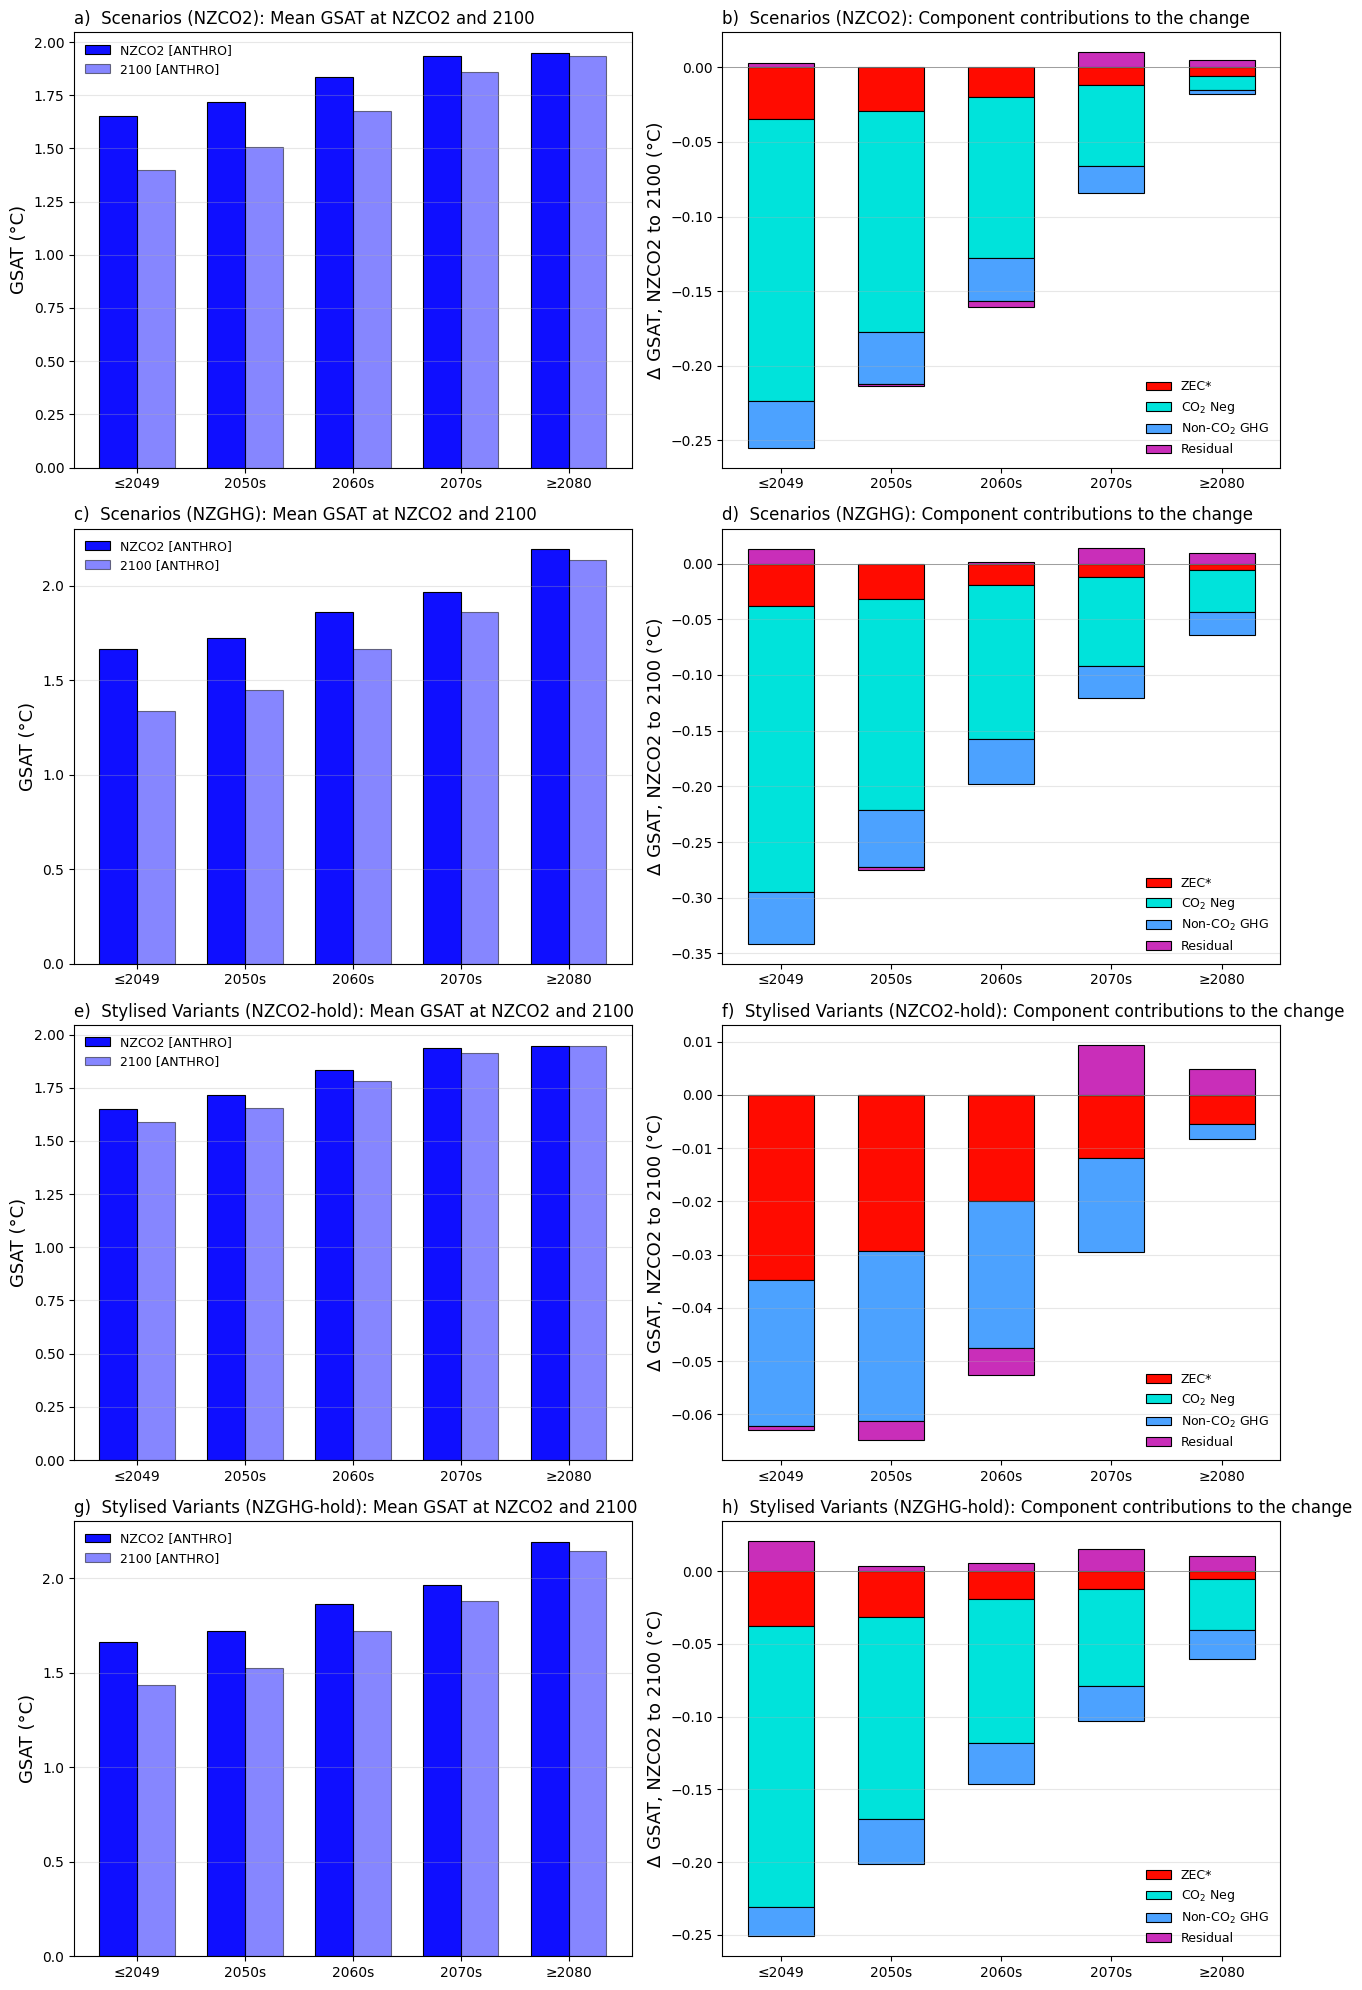

In [9]:
color_start = '#0F0FFF'
color_end = '#0F0FFF'
color_delta = {
    'CO2_NZCO2': '#FF0B00',
    'CO2_Negative': '#00E3DB',
    'NonCO2_GHG': '#4CA2FF',
    'Residual': '#C92EB9',
}
component_labels = {
    'CO2_NZCO2': 'ZEC*',
    'CO2_Negative': 'CO$_2$ Neg',
    'NonCO2_GHG': 'Non-CO$_2$ GHG',
    'Residual': 'Residual',
}

x = np.arange(len(BUCKET_ORDER))
bar_width = 0.35

fig, axes = plt.subplots(len(GROUPS), 2, figsize=(13, 5 * len(GROUPS)))

panel_labels = iter("abcdefghijklmnopqrstuvwxyz")

for row, group in enumerate(GROUPS):
    ax_a, ax_b = axes[row]
    gdf = comparison_df.loc[group].reindex(BUCKET_ORDER)

    # --- Panel a: absolute GSAT levels, NZCO2 vs 2100, grouped per bucket ---
    ax_a.bar(x - bar_width / 2, gdf["nzco2_mean"], width=bar_width,
             color=color_start, edgecolor="black", linewidth=0.8, label="NZCO2 [ANTHRO]")
    ax_a.bar(x + bar_width / 2, gdf["y2100_mean"], width=bar_width,
             color=color_end, alpha=0.5, edgecolor="black", linewidth=0.8, label="2100 [ANTHRO]")

    ax_a.set_xticks(x)
    ax_a.set_xticklabels(BUCKET_ORDER)
    ax_a.set_ylabel("GSAT (°C)", fontsize=13)
    ax_a.set_title(f"{next(panel_labels)})  {group}: Mean GSAT at NZCO2 and 2100", fontsize=12, loc="left")
    ax_a.legend(fontsize=9, frameon=False)
    ax_a.grid(alpha=0.3, axis="y")

    # --- Panel b: stacked delta components per bucket ---
    pos_bottom = np.zeros(len(gdf))
    neg_bottom = np.zeros(len(gdf))
    for comp in DELTA_COMPONENTS:
        values = gdf[comp].values
        bottoms = np.where(values >= 0, pos_bottom, neg_bottom)
        ax_b.bar(x, values, width=0.6, bottom=bottoms, color=color_delta[comp],
                  edgecolor="black", linewidth=0.8, label=component_labels[comp])
        pos_bottom = np.where(values >= 0, pos_bottom + values, pos_bottom)
        neg_bottom = np.where(values < 0, neg_bottom + values, neg_bottom)

    ax_b.set_xticks(x)
    ax_b.set_xticklabels(BUCKET_ORDER)
    ax_b.set_ylabel("Δ GSAT, NZCO2 to 2100 (°C)", fontsize=13)
    ax_b.set_title(f"{next(panel_labels)})  {group}: Component contributions to the change", fontsize=12, loc="left")
    ax_b.legend(fontsize=9, frameon=False)
    ax_b.grid(alpha=0.3, axis="y")
    ax_b.axhline(y=0, color="gray", linestyle="-", linewidth=0.5)

plt.tight_layout()
plt.savefig(PLOT_FOLDER / "507_cross_decade_comparison.png", dpi=150, bbox_inches="tight")
plt.show()


<>:55: SyntaxWarning: invalid escape sequence '\D'
<>:55: SyntaxWarning: invalid escape sequence '\D'
/var/folders/y4/5qztk4vn4fq27tgyj0wzy83m0000gn/T/ipykernel_52818/1782701712.py:55: SyntaxWarning: invalid escape sequence '\D'
  ax_b.set_title(f"{next(panel_labels)})  {group}: Mean contributions to $\Delta$ GSAT", fontsize=12, loc="left")


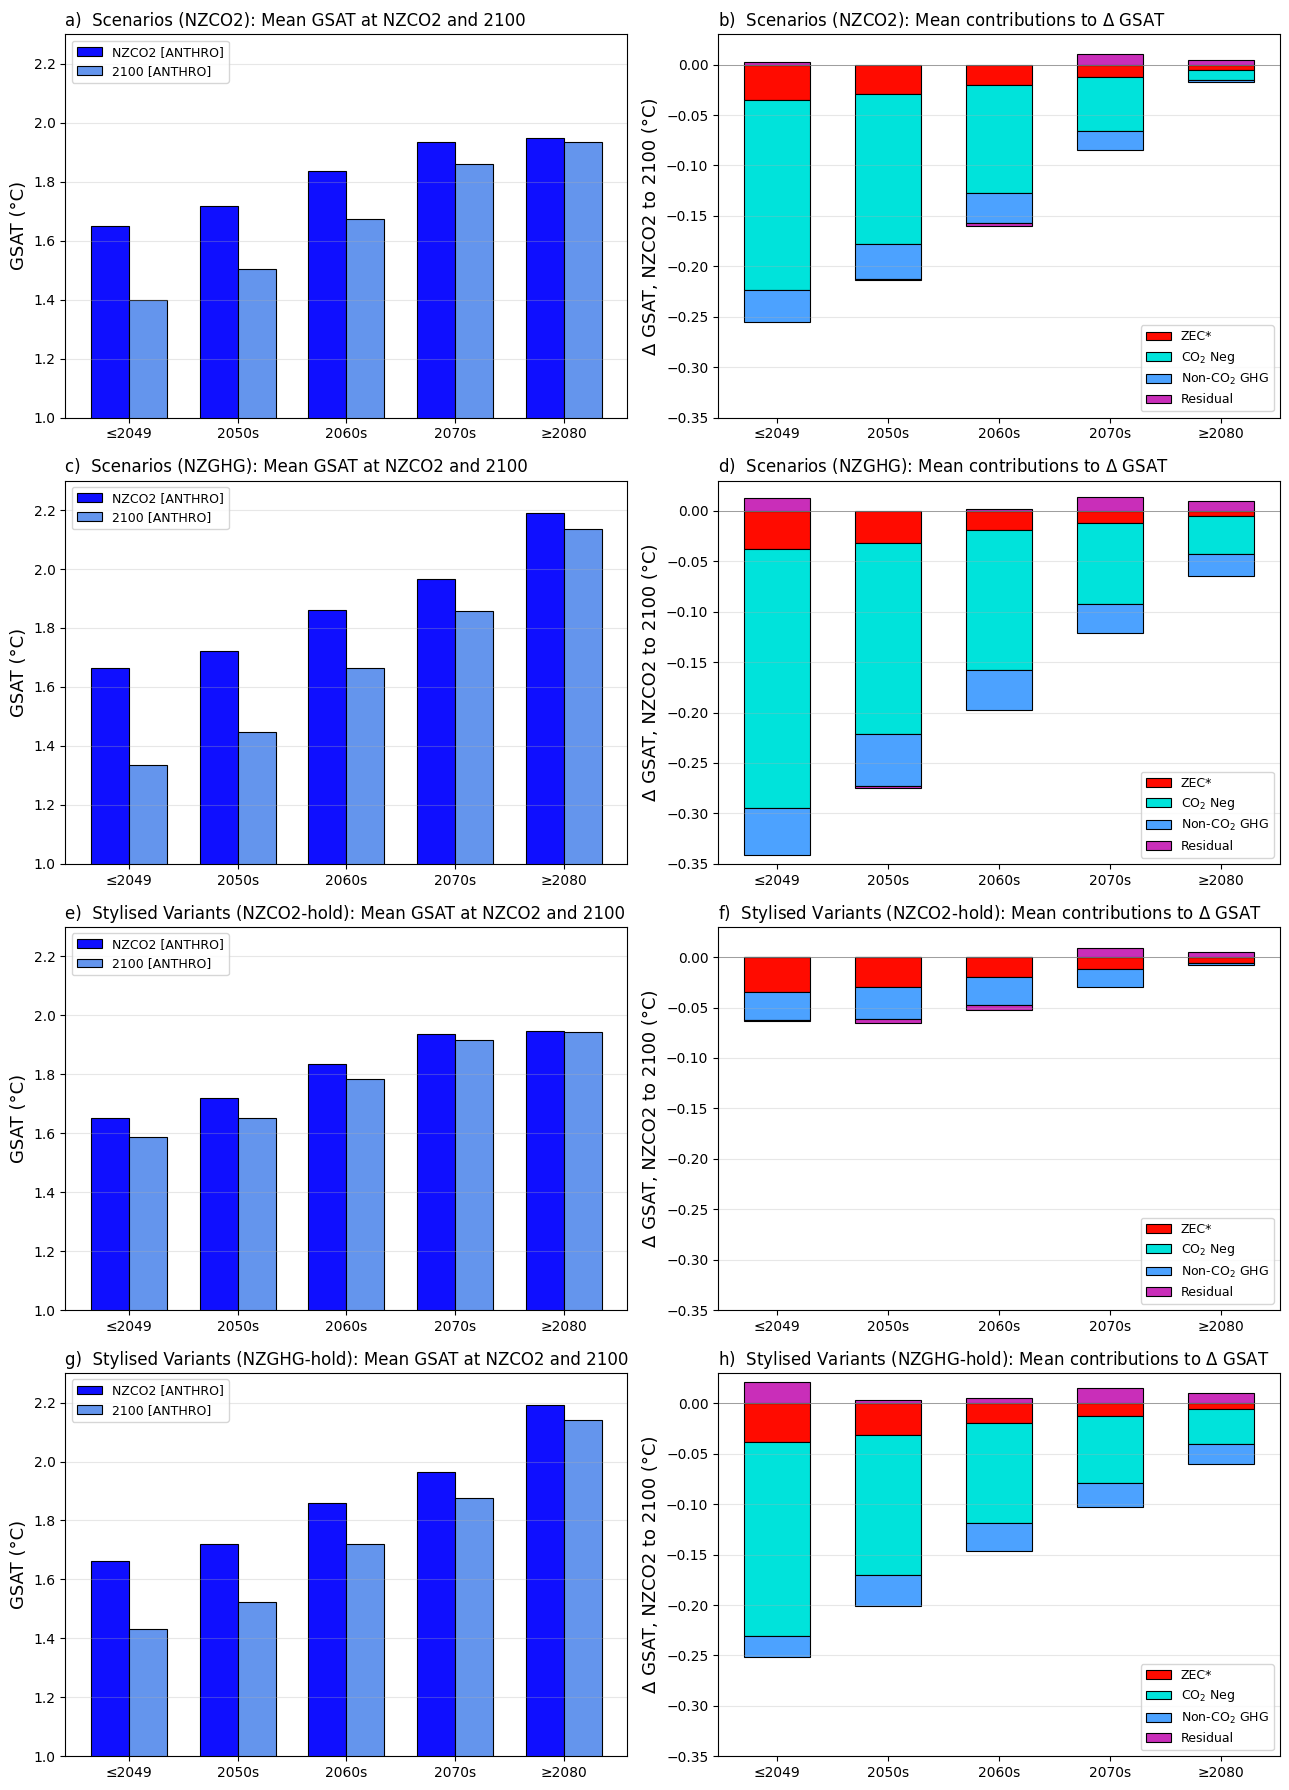

In [10]:
color_start = '#0F0FFF'
color_end = '#0F0FFF'
color_delta = {
    'CO2_NZCO2': '#FF0B00',
    'CO2_Negative': '#00E3DB',
    'NonCO2_GHG': '#4CA2FF',
    'Residual': '#C92EB9',
}
component_labels = {
    'CO2_NZCO2': 'ZEC*',
    'CO2_Negative': 'CO$_2$ Neg',
    'NonCO2_GHG': 'Non-CO$_2$ GHG',
    'Residual': 'Residual',
}

x = np.arange(len(BUCKET_ORDER))
bar_width = 0.35

fig, axes = plt.subplots(len(GROUPS), 2, figsize=(13, 4.5 * len(GROUPS)))

panel_labels = iter("abcdefghijklmnopqrstuvwxyz")

for row, group in enumerate(GROUPS):
    ax_a, ax_b = axes[row]
    gdf = comparison_df.loc[group].reindex(BUCKET_ORDER)

    # --- Panel a: absolute GSAT levels, NZCO2 vs 2100, grouped per bucket ---
    ax_a.bar(x - bar_width / 2, gdf["nzco2_mean"], width=bar_width,
             color=color_start, edgecolor="black", linewidth=0.8, label="NZCO2 [ANTHRO]")
    ax_a.bar(x + bar_width / 2, gdf["y2100_mean"], width=bar_width,
             color="cornflowerblue", edgecolor="black", linewidth=0.8, label="2100 [ANTHRO]")

    ax_a.set_xticks(x)
    ax_a.set_xticklabels(BUCKET_ORDER)
    ax_a.set_ylabel("GSAT (°C)", fontsize=13)
    ax_a.set_title(f"{next(panel_labels)})  {group}: Mean GSAT at NZCO2 and 2100", fontsize=12, loc="left")
    ax_a.set_ylim(1,2.3)
    ax_a.legend(fontsize=9, loc=2)
    ax_a.grid(alpha=0.3, axis="y")

    # --- Panel b: stacked delta components per bucket ---
    pos_bottom = np.zeros(len(gdf))
    neg_bottom = np.zeros(len(gdf))
    for comp in DELTA_COMPONENTS:
        values = gdf[comp].values
        bottoms = np.where(values >= 0, pos_bottom, neg_bottom)
        ax_b.bar(x, values, width=0.6, bottom=bottoms, color=color_delta[comp],
                  edgecolor="black", linewidth=0.8, label=component_labels[comp])
        pos_bottom = np.where(values >= 0, pos_bottom + values, pos_bottom)
        neg_bottom = np.where(values < 0, neg_bottom + values, neg_bottom)

    ax_b.set_xticks(x)
    ax_b.set_xticklabels(BUCKET_ORDER)
    ax_b.set_ylabel("Δ GSAT, NZCO2 to 2100 (°C)", fontsize=13)
    ax_b.set_title(f"{next(panel_labels)})  {group}: Mean contributions to $\Delta$ GSAT", fontsize=12, loc="left")
    ax_b.set_ylim(-0.35,0.03)
    ax_b.legend(fontsize=9, loc=4)
    ax_b.grid(alpha=0.3, axis="y")
    ax_b.axhline(y=0, color="gray", linestyle="-", linewidth=0.5)

plt.tight_layout()
plt.savefig(PLOT_FOLDER / "507_cross_decade_comparison_ylims.png", dpi=150, bbox_inches="tight")
plt.show()

## Median-Based Version (for Comparison)

Same cross-decade comparison as the ylims figure above, but using median-of-medians instead of mean-of-means for both the absolute GSAT levels and the delta components. Additivity is not preserved here (median is not additive - see 506's markdown intro), but that is an accepted tradeoff for this exploratory comparison. Same fixed y-limits as the mean version, to make the two directly comparable.

In [11]:
def calc_scenario_medians(df, groups):
    """Per-scenario MEDIAN (across ensemble members) of the endpoint GSAT levels -
    median analogue of calc_scenario_means above."""
    value_cols = [c for c in df.columns if c.startswith("GSAT|")]
    scenario_medians = df.groupby(["model", "scenario", "scenario_group"])[value_cols].median()
    return {
        group: scenario_medians[scenario_medians.index.get_level_values("scenario_group") == group]
        for group in groups
    }


def calc_median_of_median_by_group(metrics_df, components, groups, extraction_mode="netzero_co2"):
    """Median-of-medians central-tendency statistic per delta component, per
    scenario_group. NOT additive (median(A) + median(B) != median(A + B) in general -
    see 506's markdown intro), unlike the mean-of-means version above - accepted here
    since this cross-decade comparison isn't read as an exact waterfall decomposition."""
    delta_cols = [f"GSAT|{c}|delta_{extraction_mode}" for c in components if f"GSAT|{c}|delta_{extraction_mode}" in metrics_df.columns]
    scenario_medians = metrics_df.groupby(["model", "scenario", "scenario_group"])[delta_cols].median()

    results = {}
    for group in groups:
        gdf = scenario_medians[scenario_medians.index.get_level_values("scenario_group") == group]
        rows = {}
        for comp in components:
            col = f"GSAT|{comp}|delta_{extraction_mode}"
            if col not in gdf.columns:
                continue
            rows[comp] = {"median_of_median": gdf[col].median()}
        if rows:
            results[group] = pd.DataFrame(rows).T
    return results


comparison_rows_median = []
for group in GROUPS:
    for bucket in BUCKET_ORDER:
        bucket_df = metrics_df[
            (metrics_df["netzero_bucket"] == bucket)
            & (metrics_df["scenario_group"] == group)
        ]
        if bucket_df.empty:
            continue

        scenario_medians = calc_scenario_medians(bucket_df, [group])[group]
        pop_stats = calc_median_of_median_by_group(bucket_df, DELTA_COMPONENTS, [group], "netzero_co2")[group]

        row = {
            "scenario_group": group,
            "bucket": bucket,
            "n": len(scenario_medians),
            "nzco2_median": scenario_medians["GSAT|ANTHROPOGENIC|netzero_co2"].median(),
            "y2100_median": scenario_medians["GSAT|ANTHROPOGENIC|2100"].median(),
        }
        for comp in DELTA_COMPONENTS:
            row[comp] = pop_stats.loc[comp, "median_of_median"] if comp in pop_stats.index else np.nan
        comparison_rows_median.append(row)

comparison_df_median = pd.DataFrame(comparison_rows_median).set_index(["scenario_group", "bucket"])
comparison_df_median


n  nzco2_median  y2100_median  \
scenario_group                 bucket                                    
Scenarios (NZCO2)              ≤2049    50      1.627966      1.333785   
                               2050s   144      1.677921      1.451827   
                               2060s   202      1.805569      1.628741   
                               2070s   176      1.887902      1.789345   
                               ≥2080   212      1.858097      1.850996   
Scenarios (NZGHG)              ≤2049    28      1.637901      1.269091   
                               2050s    93      1.678427      1.378141   
                               2060s   138      1.830859      1.620558   
                               2070s    97      1.912680      1.785810   
                               ≥2080    31      2.126744      2.069793   
Stylised Variants (NZCO2-hold) ≤2049    50      1.627966      1.520924   
                               2050s   144      1.677921      1.595248   
                               2060s   202      1.805569      1.750307   
                               2070s   176      1.887902      1.849119   
                               ≥2080   212      1.858097      1.852158   
Stylised Variants (NZGHG-hold) ≤2049    28      1.637901      1.370039   
                               2050s    93      1.678427      1.457901   
                               2060s   138      1.830859      1.677161   
                               2070s    97      1.912680      1.801823   
                               ≥2080    31      2.126744      2.075437   

                                       CO2_NZCO2  CO2_Negative  NonCO2_GHG  \
scenario_group                 bucket                                        
Scenarios (NZCO2)              ≤2049   -0.053909     -0.188239   -0.022020   
                               2050s   -0.046705     -0.144036   -0.033895   
                               2060s   -0.034030     -0.105495   -0.028713   
                               2070s   -0.023670     -0.054444   -0.017995   
                               ≥2080   -0.012803     -0.000407   -0.002229   
Scenarios (NZGHG)              ≤2049   -0.058204     -0.222298   -0.042108   
                               2050s   -0.048711     -0.186357   -0.064333   
                               2060s   -0.033773     -0.127094   -0.043486   
                               2070s   -0.024594     -0.076751   -0.031242   
                               ≥2080   -0.014710     -0.033129   -0.023947   
Stylised Variants (NZCO2-hold) ≤2049   -0.053909      0.000000   -0.018289   
                               2050s   -0.046705      0.000000   -0.032364   
                               2060s   -0.034030      0.000000   -0.027428   
                               2070s   -0.023670      0.000000   -0.017726   
                               ≥2080   -0.012803      0.000000   -0.002214   
Stylised Variants (NZGHG-hold) ≤2049   -0.058204     -0.189358   -0.020222   
                               2050s   -0.048711     -0.134087   -0.041015   
                               2060s   -0.033773     -0.095046   -0.030627   
                               2070s   -0.024594     -0.064135   -0.028686   
                               ≥2080   -0.014710     -0.033129   -0.022598   

                                       Residual  
scenario_group                 bucket            
Scenarios (NZCO2)              ≤2049  -0.017467  
                               2050s  -0.013603  
                               2060s  -0.015883  
                               2070s   0.006482  
                               ≥2080   0.001967  
Scenarios (NZGHG)              ≤2049   0.025711  
                               2050s  -0.017117  
                               2060s  -0.011122  
                               2070s   0.011134  
                               ≥2080   0.011612  
Stylised Variants (NZCO2-hold) ≤2049  -0.022563  
                               2050s  -0.0154

<>:55: SyntaxWarning: invalid escape sequence '\D'
<>:55: SyntaxWarning: invalid escape sequence '\D'
/var/folders/y4/5qztk4vn4fq27tgyj0wzy83m0000gn/T/ipykernel_52818/1099086852.py:55: SyntaxWarning: invalid escape sequence '\D'
  ax_b.set_title(f"{next(panel_labels)})  {group}: Median contributions to $\Delta$ GSAT", fontsize=12, loc="left")


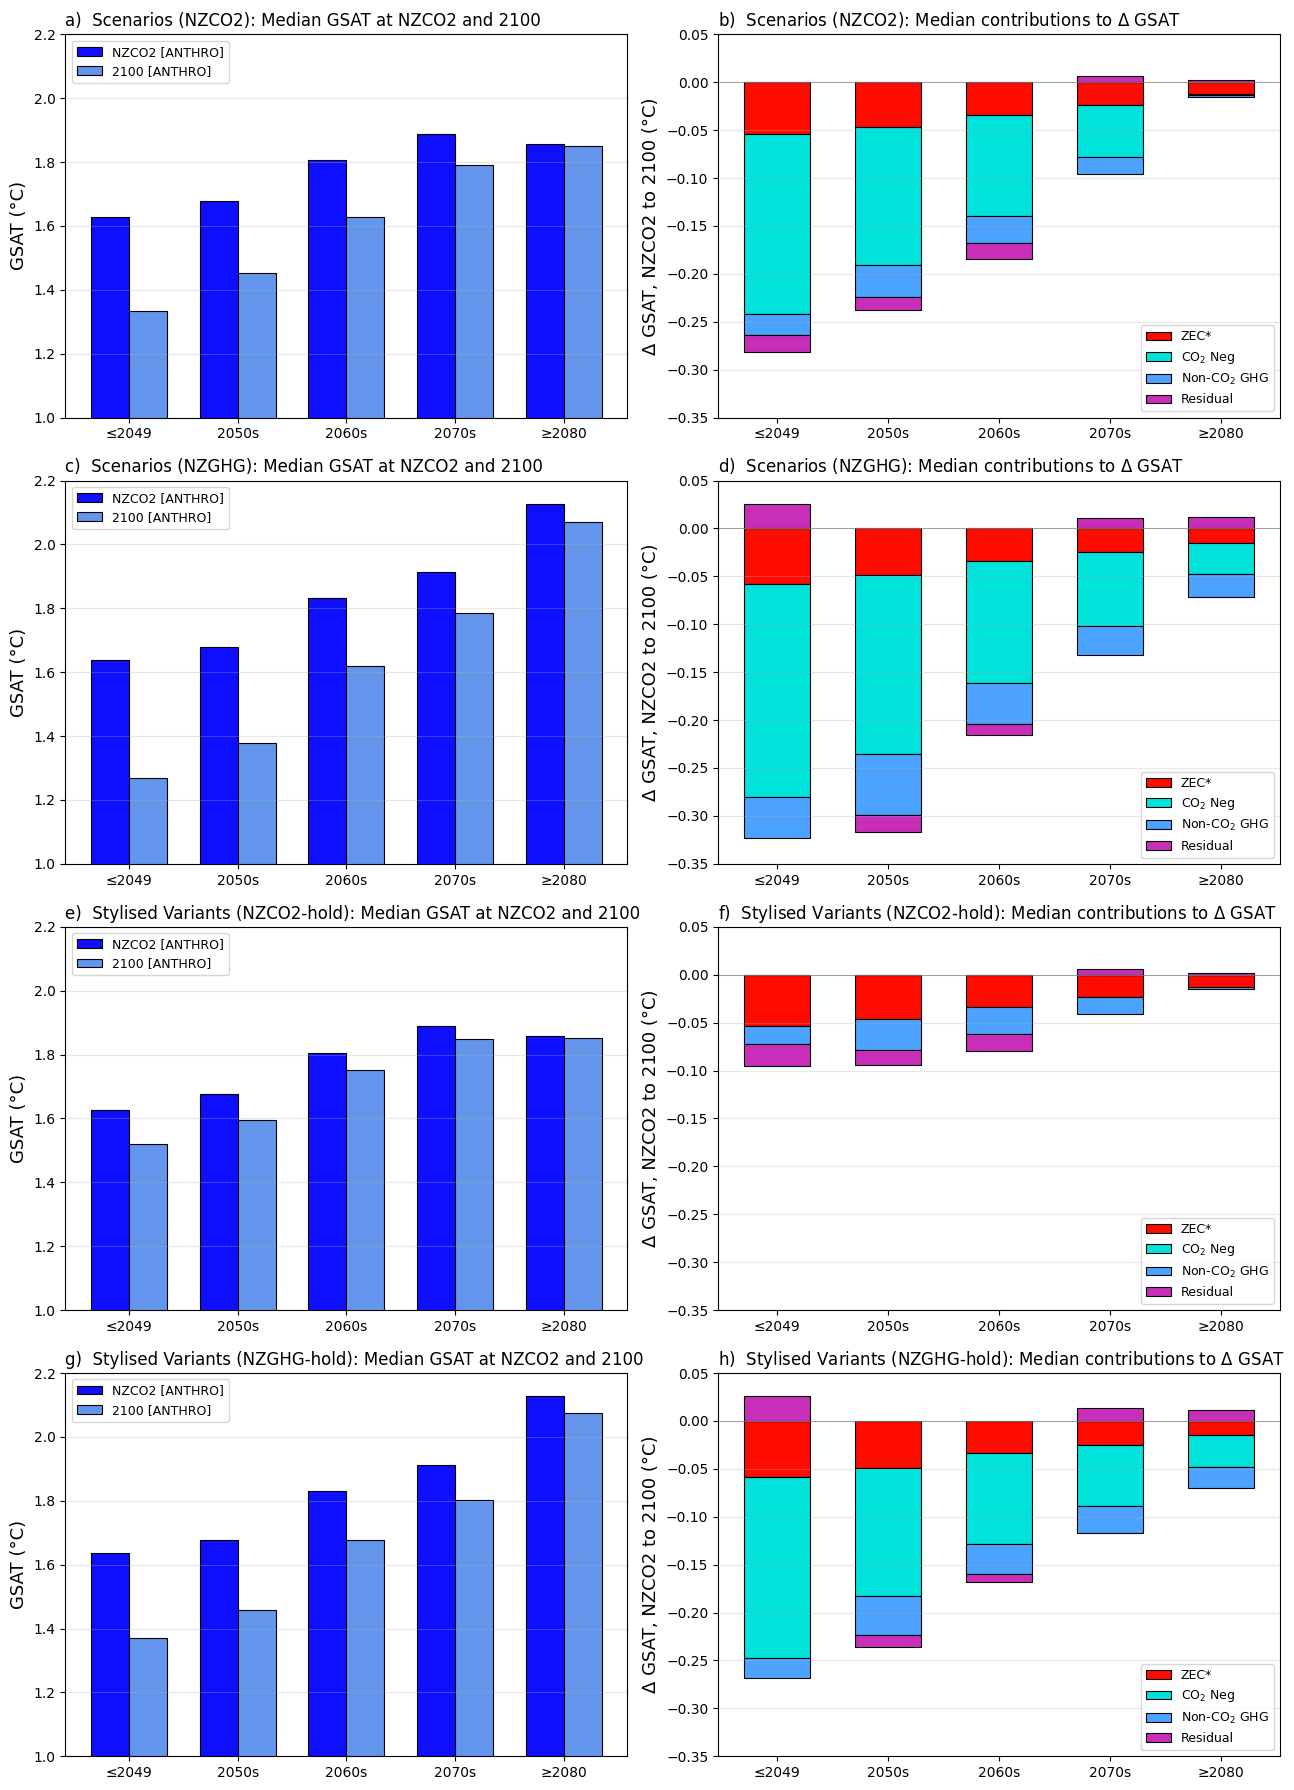

In [12]:
color_start = '#0F0FFF'
color_delta = {
    'CO2_NZCO2': '#FF0B00',
    'CO2_Negative': '#00E3DB',
    'NonCO2_GHG': '#4CA2FF',
    'Residual': '#C92EB9',
}
component_labels = {
    'CO2_NZCO2': 'ZEC*',
    'CO2_Negative': 'CO$_2$ Neg',
    'NonCO2_GHG': 'Non-CO$_2$ GHG',
    'Residual': 'Residual',
}

x = np.arange(len(BUCKET_ORDER))
bar_width = 0.35

fig, axes = plt.subplots(len(GROUPS), 2, figsize=(13, 4.5 * len(GROUPS)))

panel_labels = iter("abcdefghijklmnopqrstuvwxyz")

for row, group in enumerate(GROUPS):
    ax_a, ax_b = axes[row]
    gdf = comparison_df_median.loc[group].reindex(BUCKET_ORDER)

    # --- Panel a: absolute GSAT levels, NZCO2 vs 2100, grouped per bucket (median) ---
    ax_a.bar(x - bar_width / 2, gdf["nzco2_median"], width=bar_width,
             color=color_start, edgecolor="black", linewidth=0.8, label="NZCO2 [ANTHRO]")
    ax_a.bar(x + bar_width / 2, gdf["y2100_median"], width=bar_width,
             color="cornflowerblue", edgecolor="black", linewidth=0.8, label="2100 [ANTHRO]")

    ax_a.set_xticks(x)
    ax_a.set_xticklabels(BUCKET_ORDER)
    ax_a.set_ylabel("GSAT (°C)", fontsize=13)
    ax_a.set_title(f"{next(panel_labels)})  {group}: Median GSAT at NZCO2 and 2100", fontsize=12, loc="left")
    ax_a.set_ylim(1, 2.2)
    ax_a.legend(fontsize=9, loc=2)
    ax_a.grid(alpha=0.3, axis="y")

    # --- Panel b: stacked delta components per bucket (median-of-medians, not
    # additive - see calc_median_of_median_by_group's docstring above) ---
    pos_bottom = np.zeros(len(gdf))
    neg_bottom = np.zeros(len(gdf))
    for comp in DELTA_COMPONENTS:
        values = gdf[comp].values
        bottoms = np.where(values >= 0, pos_bottom, neg_bottom)
        ax_b.bar(x, values, width=0.6, bottom=bottoms, color=color_delta[comp],
                  edgecolor="black", linewidth=0.8, label=component_labels[comp])
        pos_bottom = np.where(values >= 0, pos_bottom + values, pos_bottom)
        neg_bottom = np.where(values < 0, neg_bottom + values, neg_bottom)

    ax_b.set_xticks(x)
    ax_b.set_xticklabels(BUCKET_ORDER)
    ax_b.set_ylabel("Δ GSAT, NZCO2 to 2100 (°C)", fontsize=13)
    ax_b.set_title(f"{next(panel_labels)})  {group}: Median contributions to $\Delta$ GSAT", fontsize=12, loc="left")
    ax_b.set_ylim(-0.35, 0.05)
    ax_b.legend(fontsize=9, loc=4)
    ax_b.grid(alpha=0.3, axis="y")
    ax_b.axhline(y=0, color="gray", linestyle="-", linewidth=0.5)

plt.tight_layout()
plt.savefig(PLOT_FOLDER / "507_cross_decade_comparison_ylims_median.png", dpi=150, bbox_inches="tight")
plt.show()
